# 06 — Baseline RUL Models (FD001)

**Phase 6 — Baseline Models**

Trains and compares:
- Linear Regression
- Random Forest Regressor
- XGBoost Regressor
- LightGBM

Evaluated with MAE, RMSE, R², and the NASA/C-MAPSS asymmetric scoring function.

In [3]:
import sys
sys.path.append('..')

import json
import pandas as pd
import matplotlib.pyplot as plt

from src.config.config import PROCESSED_DATA_DIR
from src.models.train import train_and_save_all
from src.models.predict import load_model
from src.models.evaluate import evaluate_model, compare_models

VARIANT = 'FD001'
train_fe = pd.read_parquet(PROCESSED_DATA_DIR / f'train_{VARIANT}_features.parquet')
val_fe = pd.read_parquet(PROCESSED_DATA_DIR / f'val_{VARIANT}_features.parquet')

with open(PROCESSED_DATA_DIR / f'selected_features_{VARIANT}.json') as f:
    feature_info = json.load(f)
selected_features = feature_info['selected_features']
print(f'{len(selected_features)} features selected in notebook 05')

232 features selected in notebook 05


## Train/validation matrices
Training against the **clipped** RUL target (see notebook 04 for why); the raw `RUL` column remains available in these frames if you want to compare against it directly.

In [4]:
X_train, y_train = train_fe[selected_features], train_fe['RUL_clipped']
X_val, y_val = val_fe[selected_features], val_fe['RUL_clipped']
X_train.shape, X_val.shape

((16561, 232), (4070, 232))

## Train all four baseline models
Each fitted model + its exact feature column order is saved to `models/rul/` via `src.models.train.save_model`.

In [5]:
saved_paths = train_and_save_all(X_train, y_train, variant=VARIANT)
saved_paths

[2026-10-09 06:45:40] INFO     | src.models.train | Training linear_regression on 16561 samples, 232 features...
[2026-10-09 06:45:40] INFO     | src.models.train | Finished training linear_regression
[2026-10-09 06:45:40] INFO     | src.models.train | Training random_forest on 16561 samples, 232 features...
[2026-10-09 06:46:26] INFO     | src.models.train | Finished training random_forest
[2026-10-09 06:46:26] INFO     | src.models.train | Training xgboost on 16561 samples, 232 features...
[2026-10-09 06:46:30] INFO     | src.models.train | Finished training xgboost
[2026-10-09 06:46:30] INFO     | src.models.train | Training lightgbm on 16561 samples, 232 features...
[2026-10-09 06:46:34] INFO     | src.models.train | Finished training lightgbm
[2026-10-09 06:46:34] INFO     | src.models.train | Saved model 'linear_regression' to /Users/jvpurushotham/Downloads/PrognosX/models/rul/linear_regression_FD001.joblib
[2026-10-09 06:46:34] INFO     | src.models.train | Saved model 'random_f

{'linear_regression': PosixPath('/Users/jvpurushotham/Downloads/PrognosX/models/rul/linear_regression_FD001.joblib'),
 'random_forest': PosixPath('/Users/jvpurushotham/Downloads/PrognosX/models/rul/random_forest_FD001.joblib'),
 'xgboost': PosixPath('/Users/jvpurushotham/Downloads/PrognosX/models/rul/xgboost_FD001.joblib'),
 'lightgbm': PosixPath('/Users/jvpurushotham/Downloads/PrognosX/models/rul/lightgbm_FD001.joblib')}

## Evaluate on the held-out validation engines

In [6]:
results = {}
predictions = {}
for name in saved_paths:
    model, feature_columns = load_model(name, variant=VARIANT)
    results[name] = evaluate_model(model, X_val[feature_columns], y_val)
    predictions[name] = model.predict(X_val[feature_columns])

comparison = compare_models(results)
comparison

[2026-10-09 06:46:34] INFO     | src.models.predict | Loaded model 'linear_regression' (232 features) from /Users/jvpurushotham/Downloads/PrognosX/models/rul/linear_regression_FD001.joblib
[2026-10-09 06:46:34] INFO     | src.models.predict | Loaded model 'random_forest' (232 features) from /Users/jvpurushotham/Downloads/PrognosX/models/rul/random_forest_FD001.joblib
[2026-10-09 06:46:34] INFO     | src.models.predict | Loaded model 'xgboost' (232 features) from /Users/jvpurushotham/Downloads/PrognosX/models/rul/xgboost_FD001.joblib
[2026-10-09 06:46:34] INFO     | src.models.predict | Loaded model 'lightgbm' (232 features) from /Users/jvpurushotham/Downloads/PrognosX/models/rul/lightgbm_FD001.joblib
[2026-10-09 06:46:34] INFO     | src.models.evaluate | Model comparison:
                         MAE       RMSE        R2    NASA_score  n_samples
lightgbm            8.021054  11.568345  0.923097  11059.183018     4070.0
xgboost             8.143213  11.629133  0.922287  11293.847711    

,MAE,RMSE,R2,NASA_score,n_samples
lightgbm,8.021054,11.568345,0.923097,11059.183018,4070.0
xgboost,8.143213,11.629133,0.922287,11293.847711,4070.0
random_forest,8.732888,12.602500,0.908733,13901.105128,4070.0
linear_regression,13.993701,17.051211,0.832925,20969.094423,4070.0


## Compare models visually

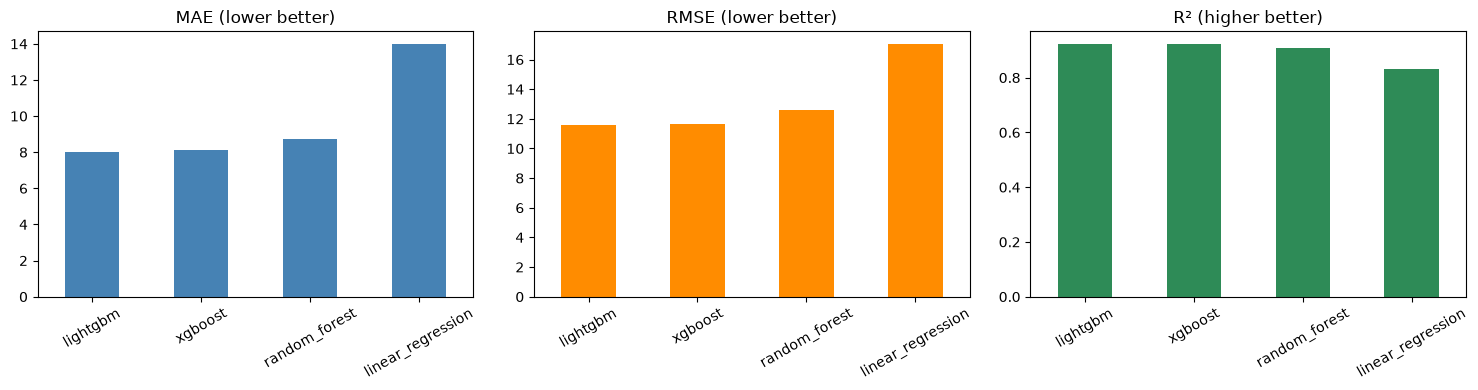

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
comparison['MAE'].plot(kind='bar', ax=axes[0], color='steelblue', title='MAE (lower better)')
comparison['RMSE'].plot(kind='bar', ax=axes[1], color='darkorange', title='RMSE (lower better)')
comparison['R2'].plot(kind='bar', ax=axes[2], color='seagreen', title='R² (higher better)')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## Actual vs. predicted RUL — best model

Best baseline model by RMSE: lightgbm


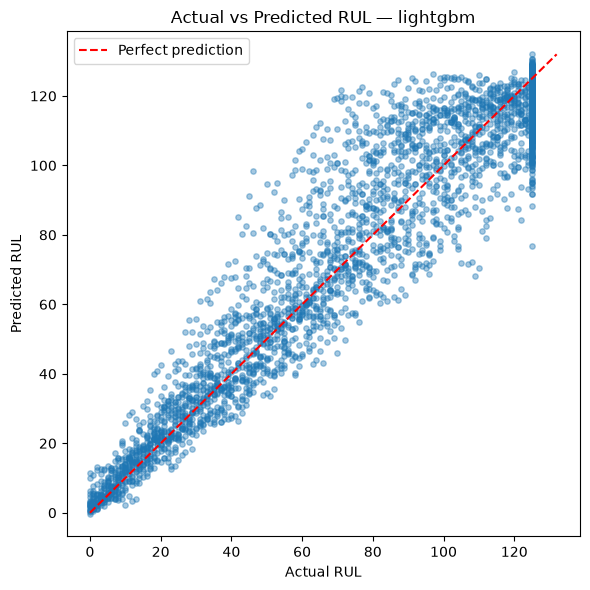

In [8]:
best_model_name = comparison.index[0]
print('Best baseline model by RMSE:', best_model_name)

plt.figure(figsize=(6, 6))
plt.scatter(y_val, predictions[best_model_name], alpha=0.4, s=15)
lims = [0, max(y_val.max(), predictions[best_model_name].max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual RUL'); plt.ylabel('Predicted RUL')
plt.title(f'Actual vs Predicted RUL — {best_model_name}')
plt.legend(); plt.tight_layout(); plt.show()

In [9]:
comparison.to_csv('../reports/metrics/baseline_model_comparison_FD001.csv')
print('Saved comparison table to reports/metrics/baseline_model_comparison_FD001.csv')

Saved comparison table to reports/metrics/baseline_model_comparison_FD001.csv


## Next
Continue to **07_xgboost_model.ipynb** for a hyperparameter-tuned deep dive on the strongest tree-based baseline, then **08_lstm_gru_model.ipynb** for the Phase 7 deep sequence models.